# Student Placement & Salary Prediction using Machine Learning

This project aims to:
- Predict whether a student gets placed (classification)
- Predict the expected salary (regression)

The project follows an end-to-end machine learning workflow including : \
- data preprocessing
- feature engineering
- model training
- hyperparameter tuning
- evaluation


## Problem Statement

Educational institutions want to understand which factors influence:
- Student placement outcomes
- Salary offered during placements

Using student academic, skill, and background data, we build:
- A classification model to predict placement status
- A regression model to predict salary (LPA)


## Importing Required Libraries

We import libraries for:
- Data handling (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine learning (scikit-learn)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from plotly import express as px

## Loading the Dataset

The dataset is loaded using pandas.
Initial inspection is performed to understand structure and data types.

In [3]:
student = pd.read_csv('../data/students.csv')
placement = pd.read_csv('../data/placement.csv')

## Exploratory Data Analysis (EDA)

In this section, we:
- Inspect column types
- Check for missing values
- Analyze basic statistics


In [4]:
student.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [9]:
placement.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


In [10]:
df = pd.merge(student, placement, on='Student_ID', how='inner')

In [11]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   str    
 2   branch                       5000 non-null   str    
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rating        

In [13]:
df.describe()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [14]:
df.isnull().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
placement_status                  0
salary_lpa                        0
dtype: int64

## Dataset Description

The dataset contains information about students such as:
- Academic performance (CGPA, 12th percentage, backlogs)
- Skills and practical experience
- Demographic and background attributes
- Placement status and salary

Target variables:
- `placement_status` (classification)
- `salary_lpa` (regression)


In [15]:
df['extracurricular_involvement'].unique()

<StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str

In [16]:
df.dtypes

Student_ID                       int64
gender                             str
branch                             str
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                      str
family_income_level                str
city_tier                          str
internet_access                    str
extracurricular_involvement        str
placement_status                   str
salary_lpa                     float64
dtype: object

<Axes: xlabel='placement_status', ylabel='count'>

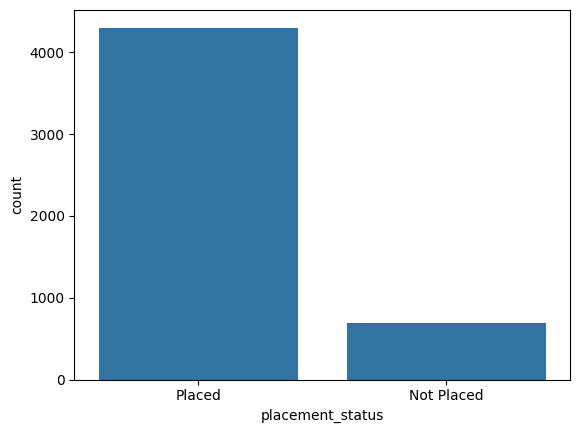

In [17]:
sns.countplot(data=df, x='placement_status')

<Axes: xlabel='salary_lpa', ylabel='Count'>

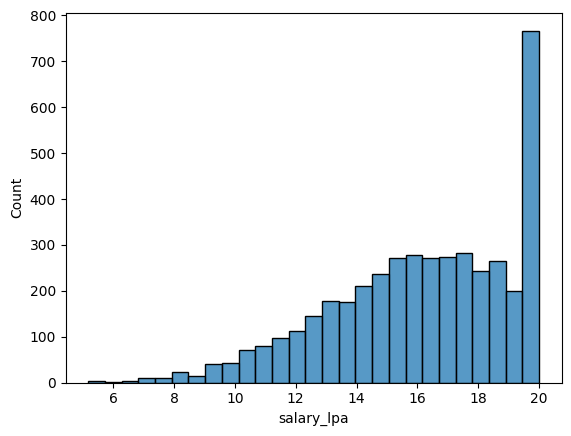

In [18]:
sns.histplot(df[df["placement_status"] == "Placed"], x='salary_lpa')

<Axes: xlabel='cgpa', ylabel='Count'>

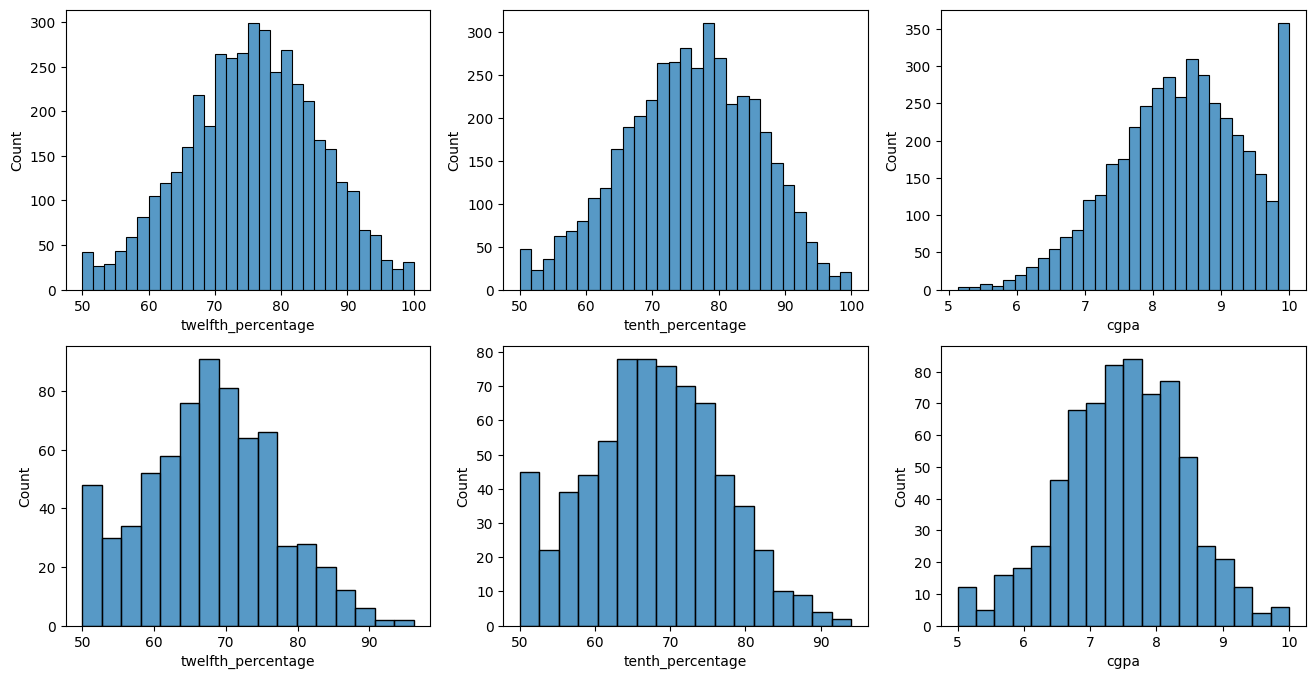

In [19]:
placed = df[df["placement_status"] == "Placed"]
nalle = df[df["placement_status"] == "Not Placed"]

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(data=placed, x='twelfth_percentage', ax=axs[0, 0])
sns.histplot(data=placed, x='tenth_percentage', ax=axs[0, 1])
sns.histplot(data=placed, x='cgpa', ax=axs[0, 2])

sns.histplot(data=nalle, x='twelfth_percentage', ax=axs[1, 0])
sns.histplot(data=nalle, x='tenth_percentage', ax=axs[1, 1])
sns.histplot(data=nalle, x='cgpa', ax=axs[1, 2])


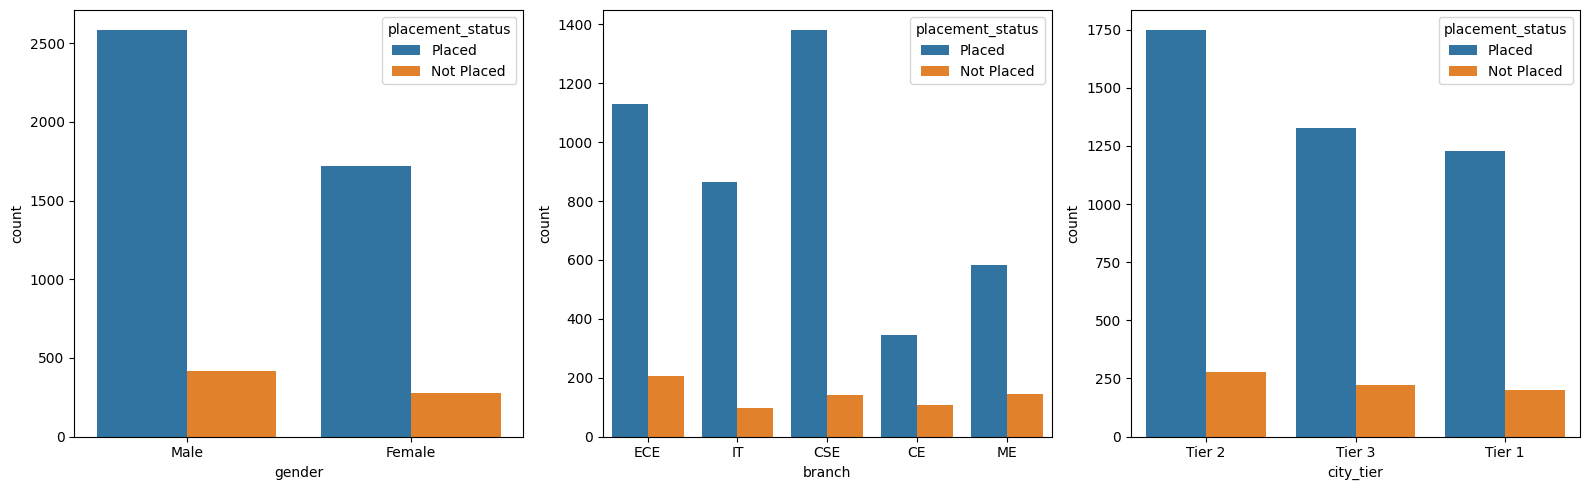

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='gender', hue='placement_status', ax=axs[0])
sns.countplot(data=df, x='branch', hue='placement_status', ax=axs[1])
sns.countplot(data=df, x='city_tier', hue='placement_status', ax=axs[2])

plt.tight_layout()

<Axes: xlabel='placement_status', ylabel='attendance_percentage'>

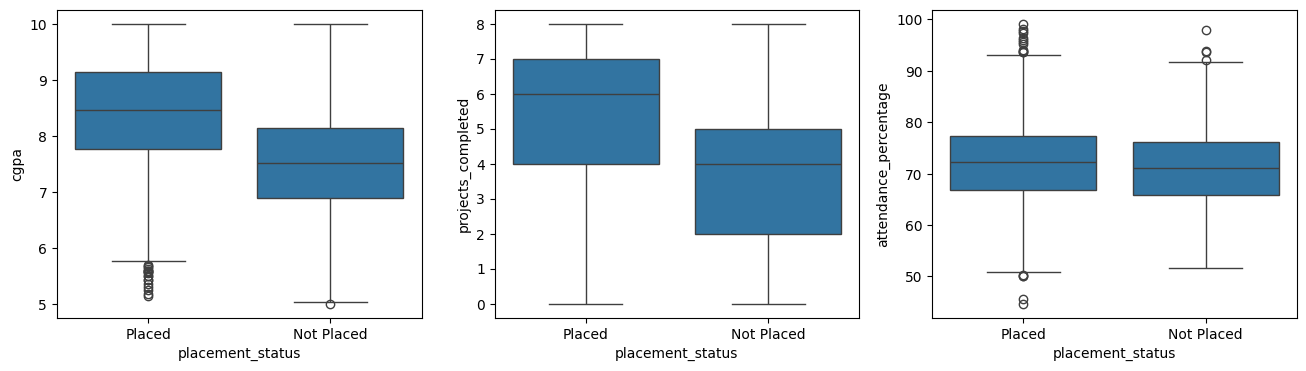

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, y='cgpa', x='placement_status', ax=axs[0])
sns.boxplot(data=df, y='projects_completed', x='placement_status', ax=axs[1])
sns.boxplot(data=df, y='attendance_percentage', x='placement_status', ax=axs[2])

## Handling Categorical Features

Machine learning models require numerical input.
Categorical variables are encoded using appropriate techniques such as:
- Label encoding
- Mapping ordinal categories


In [77]:
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(df['extracurricular_involvement'].mode()[0])

In [22]:
job_map = {'Placed' : True, 'Not Placed' : False}

df['placement_status'] = df['placement_status'].map(job_map)

df['placement_status'] = df['placement_status'].astype(int)

In [27]:
ord_map = {
    'gender' : {'Male' : 1, 'Female' : 0},
    'part_time_job' : {'Yes': 1, 'No' : 0},
    'internet_access' : {'Yes' : 1, 'No' : 0},
    'family_income_level' : {'Medium' : 2, 'Low' : 1, 'High' : 3},
    'city_tier' : {'Tier 2' : 2, 'Tier 3' : 3, 'Tier 1' : 1},
    'extracurricular_involvement' : {'Medium' : 2, 'Low':1, 'High' : 3}
    
}

for col, mapp in ord_map.items():
    df[col] = df[col].map(mapp).astype('int')

In [28]:
df_encoded = pd.get_dummies(df, columns=['branch'])

## Feature Engineering

New features are created to improve model learning.
Similar attributes such as projects, internships, hackathons, and ratings
are combined into higher-level features like:
- `practical_experience`
- `skill_rating`

This helps reduce noise and multicollinearity.


In [24]:
df['practical_expereince'] = (df['projects_completed'] + df['internships_completed'] + df['hackathons_participated'])
df["skill_rating"] = (0.5*df["coding_skill_rating"] + 0.2*df["communication_skill_rating"] + 0.3*df["aptitude_skill_rating"])

In [25]:
cols = ['tenth_percentage', 'study_hours_per_day', 'attendance_percentage', 'projects_completed',
'internships_completed', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating','hackathons_participated','sleep_hours',
 'stress_level', 'Student_ID', 'certifications_count']

df = df.drop(columns=cols)

<Axes: >

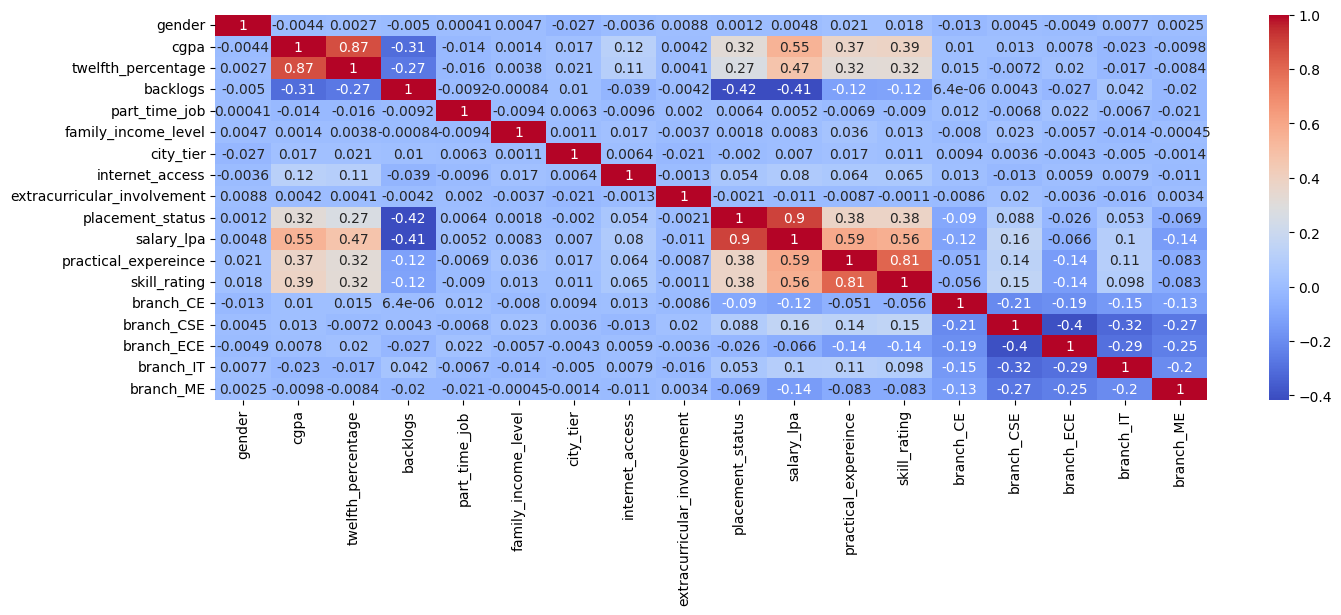

In [29]:
plt.figure(figsize=(16, 5))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap="coolwarm")

## Feature Selection

Features with very low correlation were analyzed carefully.
Instead of blindly dropping features, decisions were made based on:
- Domain relevance
- Redundancy with other features
- Model type (tree-based models handle weak correlations better)

Final feature set balances simplicity and predictive power.


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, mean_squared_error, f1_score, accuracy_score, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

## Train-Test Split

The dataset is split into training and testing sets:
- 80% for training
- 20% for testing

Stratified sampling is used for classification
to preserve class distribution.


In [63]:
x = df_encoded.drop(['placement_status', 'salary_lpa'], axis=1)
y = df_encoded['placement_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=67, stratify=y)

In [69]:
df_placed = df[df['placement_status'] == 1]

u = df_encoded.drop(['placement_status', 'salary_lpa'], axis=1)
v = df_encoded['salary_lpa']

u_train, u_test, v_train, v_test = train_test_split(u, v, test_size=0.2, random_state=67)

## Placement Prediction Model (Classification)

A Random Forest Classifier is used because:
- It handles non-linear relationships well
- It works effectively with mixed feature types
- It is robust to outliers

## Handling Class Imbalance

The dataset is imbalanced (more placed than not placed students).
To address this:
- `class_weight='balanced'` is used
- Evaluation focuses on precision, recall, and F1-score instead of accuracy alone

## Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV is used instead of GridSearchCV because:
- It is faster on larger datasets
- It explores a wider parameter space efficiently

The objective is to maximize macro F1-score.

In [52]:
rf_clf = RandomForestClassifier(random_state=67, class_weight='balanced')

params_clf = {
    'n_estimators' : [100, 200, 300, 400],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2']
}

rand_clf = RandomizedSearchCV(
    estimator = rf_clf,
    param_distributions = params,
    n_iter=40,
    cv=5, 
    scoring='f1_macro',
    random_state=67,
    n_jobs=-1
)

rand_clf.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=67)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [53]:
best_clf = random_search.best_estimator_

y_pred = best_clf.predict(x_test)

## Classification Results

Model performance is evaluated using:
- Precision
- Recall
- F1-score
- Confusion matrix

These metrics provide better insight than accuracy alone.


In [54]:
report_cl = classification_report(y_test, y_pred)
print(report_cl)

              precision    recall  f1-score   support

           0       0.54      0.70      0.61       139
           1       0.95      0.90      0.93       861

    accuracy                           0.87      1000
   macro avg       0.74      0.80      0.77      1000
weighted avg       0.89      0.87      0.88      1000



Text(0.5, 1.0, 'Confusion Matrix - Placement Prediction')

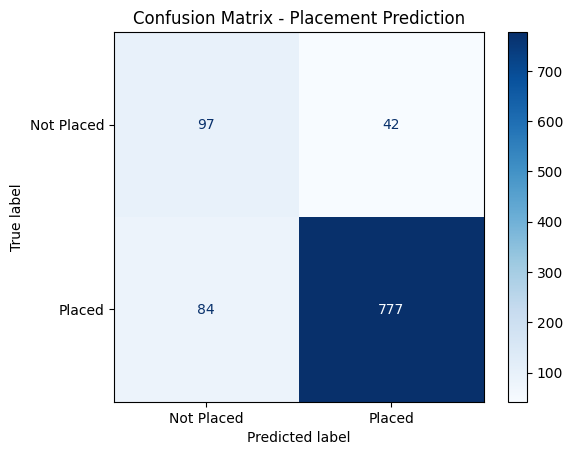

In [82]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Placed', 'Placed'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Placement Prediction")

## Classification Performance Analysis

The model shows:
- High recall for placed students
- Improved recall for non-placed students after class balancing

This indicates the model is suitable for identifying at-risk students.

## Salary Prediction Model (Regression)

For salary prediction:
- A Random Forest Regressor is used
- The task is treated separately from placement prediction

In [70]:
rf_reg = RandomForestRegressor(random_state=67)

params_reg = {
    'n_estimators' : [100, 200, 300, 400],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2']
}

rand_reg = RandomizedSearchCV(
    estimator = rf_reg,
    param_distributions = params,
    n_iter=40,
    cv=5, 
    scoring='neg_root_mean_squared_error',
    random_state=67,
    n_jobs=-1
)

rand_reg.fit(u_train, v_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=67)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategi

In [71]:
best_reg = rand_reg.best_estimator_

z_pred = best_reg.predict(x_test)

## Regression Evaluation

The regression model is evaluated using:
- R² score
- Root Mean Squared Error (RMSE)

These metrics indicate both accuracy and error magnitude.


In [73]:
r2 = r2_score(z_test, z_pred)
print(r2)

0.7591830537913812


In [75]:
rmse = mean_squared_error(z_test, z_pred)**0.5
rmse

3.0526985435958927

## Regression Results Analysis

The final regression model achieved:
- R² score of approximately 0.75
- RMSE around 3 LPA

This suggests the model explains most salary variance reasonably well.


## Conclusion

This project demonstrates:
- End-to-end ML workflow
- Effective feature engineering
- Proper handling of class imbalance
- Use of hyperparameter tuning

Both models perform well and provide meaningful insights.


## Future Improvements

Possible enhancements include:
- Trying XGBoost or LightGBM
- Feature importance visualization
- Model deployment using Flask or FastAPI
- Separate salary model only for placed students
